## Plot a Historgram of baselines

In [1]:
from astropy.coordinates import EarthLocation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import importlib
import sys
importlib.invalidate_caches()
sys.modules.pop("uv_utils", None)
from uv_utils import (
    utm_txt_to_earthlocations,
    combine_locations,
    setup_uvdata,
    plot_antenna_positions,
    plot_uv_coverage,
    compute_dirty_beam,
    adaptive_briggs_sweep,
    plot_briggs_values,
    _apply_weighting
)

drao_loc = EarthLocation.of_site("DRAO")
FREQ_HZ = 900e6

Loaded 512 antennas from '../geo_data/layouts/shifted_SW_trimmed2.txt'


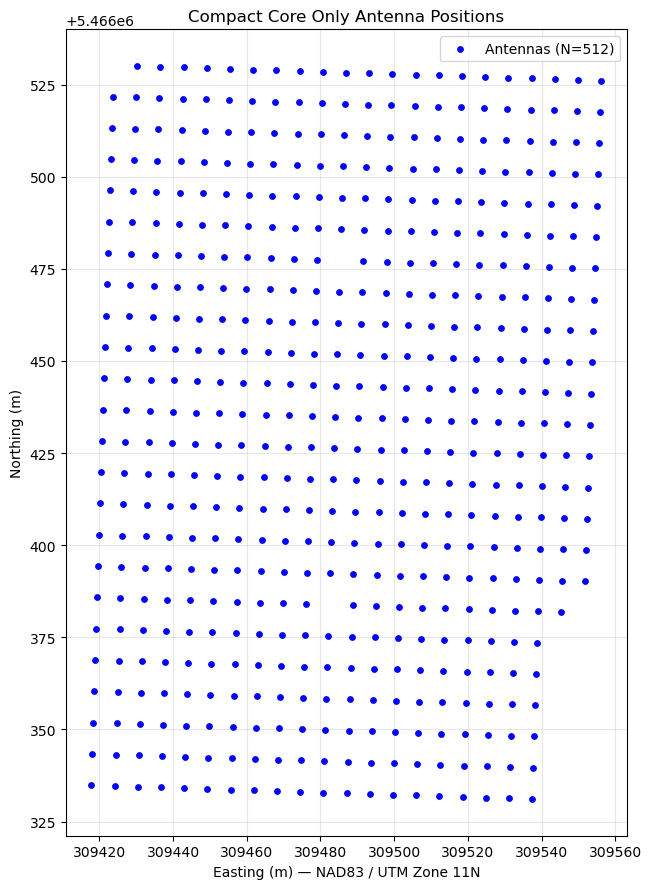

In [2]:
compact    = utm_txt_to_earthlocations("../geo_data/layouts/shifted_SW_trimmed2.txt")
plot_antenna_positions(compact,    title="Compact Core Only")

In [3]:
uvd_compact    = setup_uvdata(compact,    drao_loc, freq_hz=FREQ_HZ, n_times=1, obs_duration_hours=1)

Unknown polarization basis -- assuming linearly polarized (x/y) feeds for Telescope.feed_array.
Parameter feed_array, feed_angle, and mount_type must be set together. Unsetting optional parameters.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.
Recalculating uvw_array without adjusting visibility phases -- this can introduce significant errors if used incorrectly.
itrs position vector magnitudes must be on the order of the radius of Earth -- they appear to lie well above this.


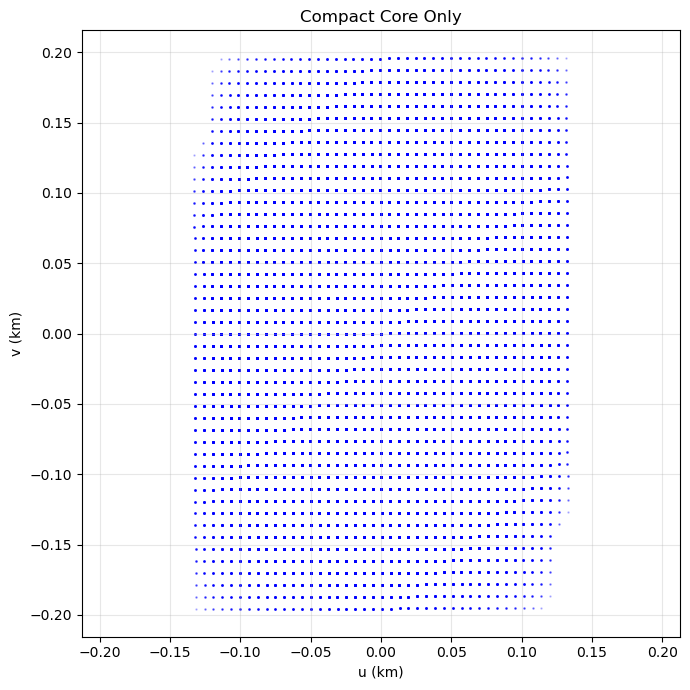

Compact Core Only: max baseline =    0.2 km -> resolution ~ 291.3 arcsec


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Compact Core Only'}, xlabel='u (km)', ylabel='v (km)'>,
 np.float64(291.25094105767977))

In [4]:
plot_uv_coverage(uvd_compact,    "Compact Core Only",              freq_hz=FREQ_HZ)

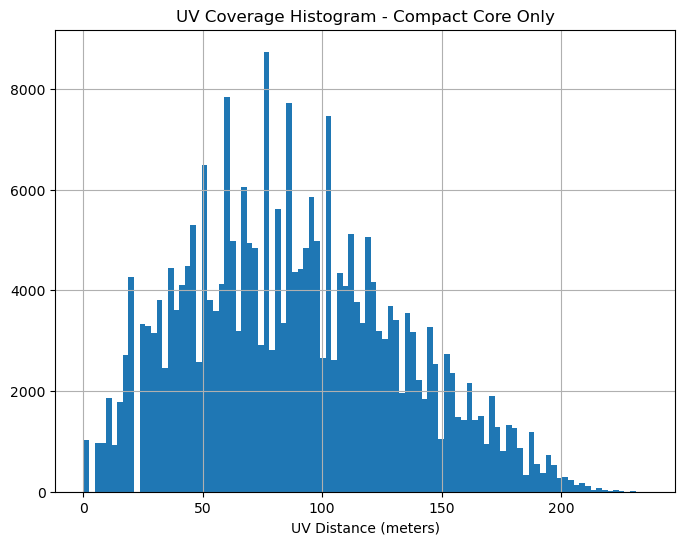

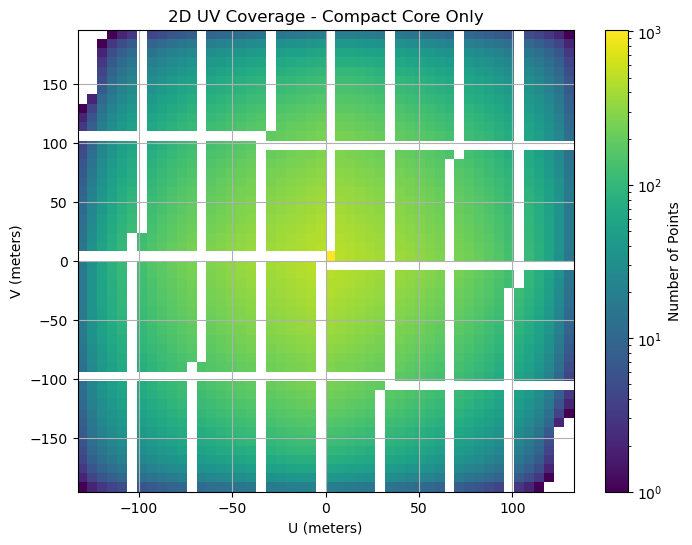

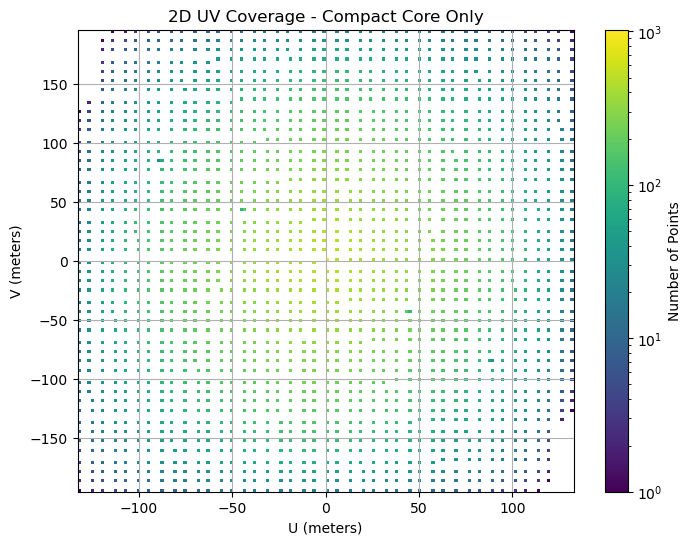

In [5]:
# Get UV from pyUVData object 
u = uvd_compact.uvw_array[:, 0]
v = uvd_compact.uvw_array[:, 1]

# Add in the negative UV points for plotting
u = np.concatenate([u, -u])
v = np.concatenate([v, -v])

uv_total = np.sqrt(u**2 + v**2)
#plot a histogram of the UV points
plt.figure(figsize=(8, 6))
plt.hist(uv_total, bins=100)
plt.xlabel('UV Distance (meters)')
plt.title('UV Coverage Histogram - Compact Core Only')
plt.grid()
plt.show()

# plot 2d histogram of the UV points
plt.figure(figsize=(8, 6))
plt.hist2d(u, v, bins=50, norm=colors.LogNorm())
plt.xlabel('U (meters)')
plt.ylabel('V (meters)')
plt.title('2D UV Coverage - Compact Core Only')
plt.colorbar(label='Number of Points')
plt.grid()
plt.show()

# plot 2d histogram of the UV points
plt.figure(figsize=(8, 6))
plt.hist2d(u, v, bins=150, norm=colors.LogNorm())
plt.xlabel('U (meters)')
plt.ylabel('V (meters)')
plt.title('2D UV Coverage - Compact Core Only')
plt.colorbar(label='Number of Points')
plt.grid()
plt.show()

Histogram in u and in v

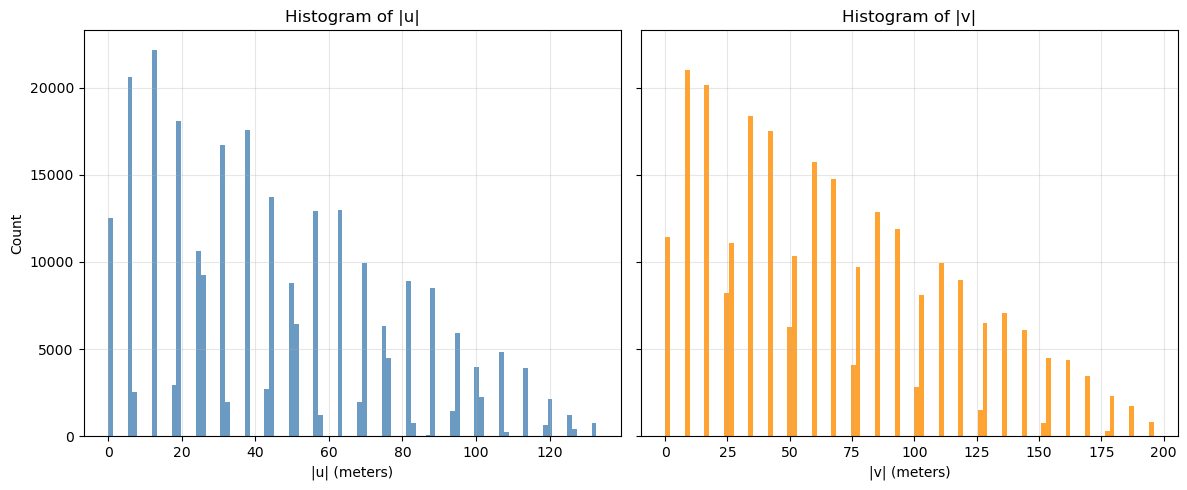

In [6]:

# Histogram of u and v separately
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(abs(u), bins=100, color="steelblue", alpha=0.8)
axes[0].set_title("Histogram of |u|")
axes[0].set_xlabel("|u| (meters)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(abs(v), bins=100, color="darkorange", alpha=0.8)
axes[1].set_title("Histogram of |v|")
axes[1].set_xlabel("|v| (meters)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
